<a href="https://colab.research.google.com/github/Sebacaraballo/ME239---Data-Science-for-ME/blob/main/lecture10/homework_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(lecture10:homework)=
# Homework 10

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Sebastian
+ **Last Name:** Caraballo
+ **Email:** scarabal@purdue.edu

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import numpy as np
import scipy.stats as st

/tmp/ipykernel_607/122018214.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


(lecture10:homework:problem1)=
## Problem 1 - An alternative way to construct the generalized uniform distribution $U([a,b])$

Let $Z$ be a standard uniform random variable:

$$
Z\sim U([0,1]).
$$

Define the random variable:

$$
X = a + (b-a) Z.
$$

+ Show that:

$$
X\sim U([a,b]).
$$

Hint: Prove that the CDF of $X$ is $F_X(x) = p(X\le x) = \frac{x-a}{b-a}$. This is one line.

**Answer:**
<br><br>F_X(x) = p(X ≤ x) = p(a + (b-a)Z ≤ x) = p(Z ≤ (x-a)/(b-a)) = (x-a)/(b-a)
since Z~U([0,1]) has CDF F_Z(z) = z. This is exactly the CDF of U([a,b])

+ The function `numpy.random.rand` gives you uniform random samples in $[0, 1]$.
Take 1,000 such samples and transform them to uniform samples in $[-1, 5]$.
Hint: Fill in the missing code below.

In [2]:
a = -1
b = 5
z = np.random.rand(1000)
x = a + (b - a) * z

Test if you are getting the right answer by doing the histogram of your samples (it should be almost flat between -1 and 5):

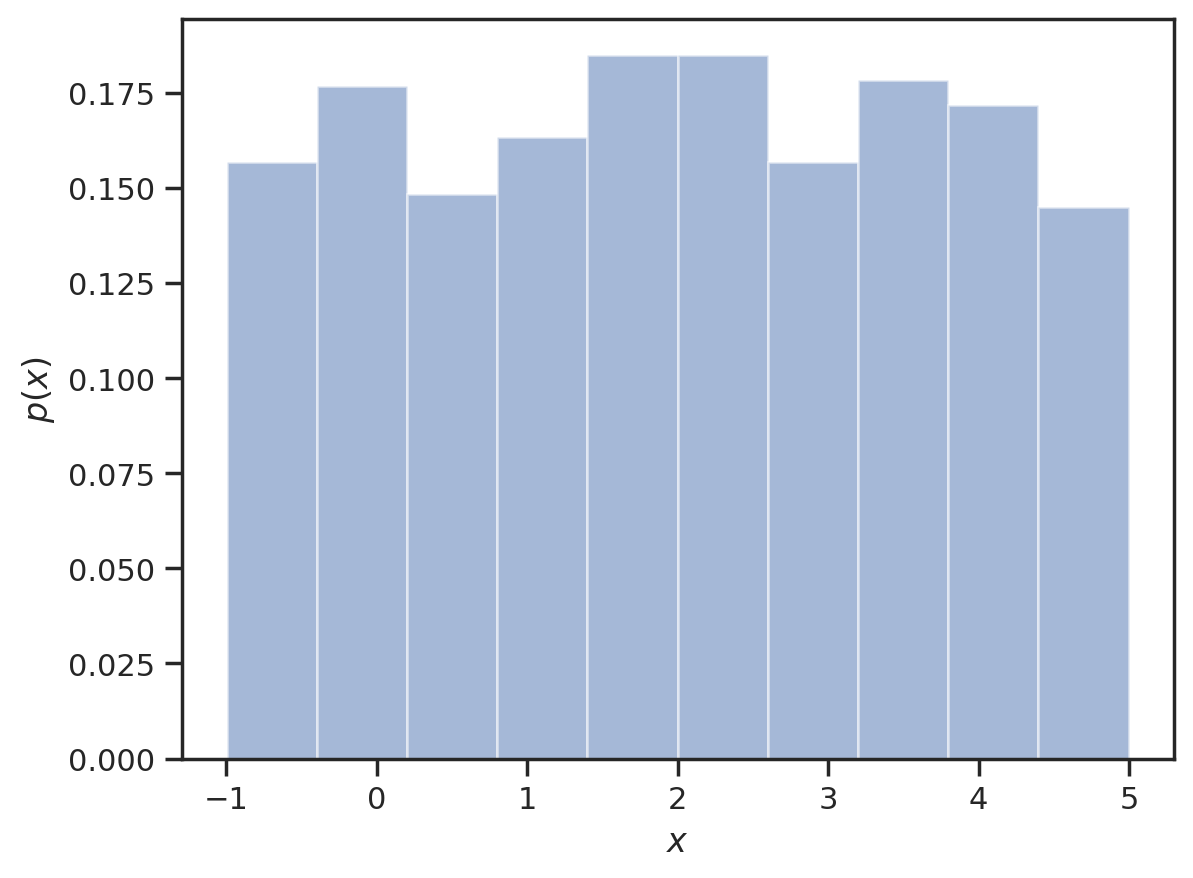

In [3]:
fig, ax = plt.subplots()
ax.hist(x, density=True, alpha=0.5)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x)$');

(lecture10:homework:problem2)=
# Problem 2 - The Exponential distribution

The Exponential distribution models the probability distribution of the time between events which occur [continuously and independently at a constant rate](https://en.wikipedia.org/wiki/Exponential_distribution).
Examples of such a situation are:
+ The time between phone calls in a help center.
+ The time between the arrival of cars at a toll station.
+ The time between the arrival of customers.
+ The time between two earthquakes.
+ The time between two micrometeoroid impacts on an Moon research base.
+ The time between faults in a mechanical system. However, this is a gross approximation because the rate of faults in a mechanical system increases with time, it is not constant.

We write:

$$
T \sim \text{Exp}(\lambda),
$$

and we read:

> $T$ follows an Exponential distribution with rate parameter $\lambda$.

The rate parameter $\lambda$ is positive and has units of inverse time.
You can think of $\lambda$ as the number of events per unit of time.

The CDF of the Exponential is:

$$
F(t) = \begin{cases}
0,& t < 0,\\
1 - e^{-\lambda t},& t \ge 0.
\end{cases}
$$

+ Prove mathematically that the PDF of the random variable $T$ is:

$$
p(t) = \lambda e^{-\lambda t}.
$$

Hint: Use one of the properties of the PDF.

**Answer:**
<br><br><br>The PDF is the derivative of the CDF:
p(t) = dF/dt = d/dt[1 - e^(-λt)] = λe^(-λt) for t ≥ 0, and 0 otherwise.

+ [Micrometeoroids](https://en.wikipedia.org/wiki/Micrometeoroid) make space exploration very challenging.
Even though the mass of these projectiles is very small (less than 1 gram), they move with a very high-velocity
(of the order of 10 km per second) and thus they are will be gradually degrading the protective layers of deep space habitats.
For a Moon base with an area of 1000 squared meters, the rate of micrometeoroid impacts is about:

$$
\lambda = 3\times 10^{-6}\;\text{s}^{-1}.
$$

Read the [scipy.stats.expon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html) documentation and make an Exponential random variable $T$ with this rate:

In [4]:
from scipy import stats as st

lam = 3e-6  # inverse seconds
T = st.expon(scale=1/lam)

+ Take 1000 samples from the random variable you just constructed and draw their histogram.


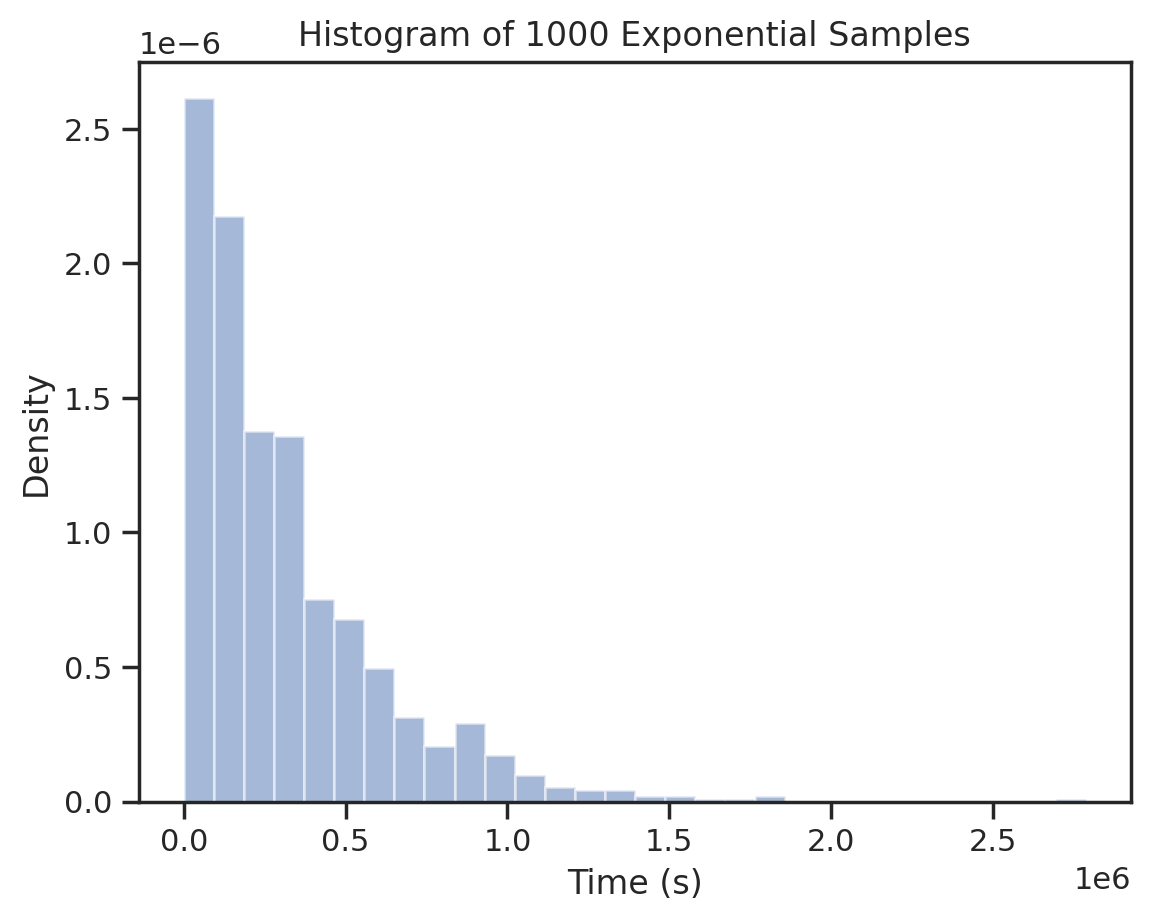

In [5]:
samples = T.rvs(1000)

fig, ax = plt.subplots()
ax.hist(samples, density=True, alpha=0.5, bins=30)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Density')
ax.set_title('Histogram of 1000 Exponential Samples');

+ Plot the CDF of $T$:

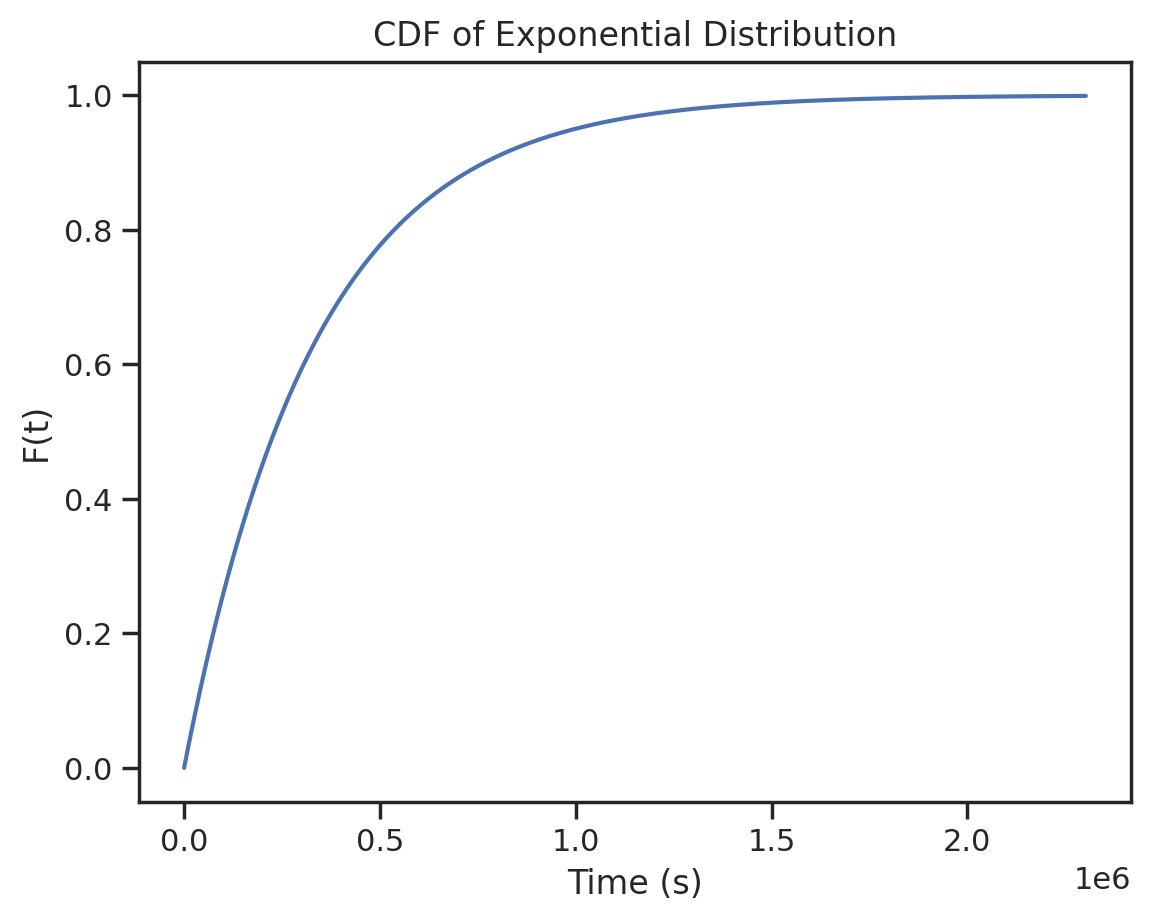

In [6]:
t = np.linspace(0, T.ppf(0.999), 500)

fig, ax = plt.subplots()
ax.plot(t, T.cdf(t))
ax.set_xlabel('Time (s)')
ax.set_ylabel('F(t)')
ax.set_title('CDF of Exponential Distribution');

+ Find the probability that we have a micrometeoroid impact within a day.
Hint: Remember that the units of $T$ are seconds.

In [7]:
one_day_seconds = 24 * 60 * 60  # 86400 seconds
p_impact = T.cdf(one_day_seconds)
print(f'P(impact within 1 day) = {p_impact:.4f}')

P(impact within 1 day) = 0.2283


+ Plot the PDF of T.

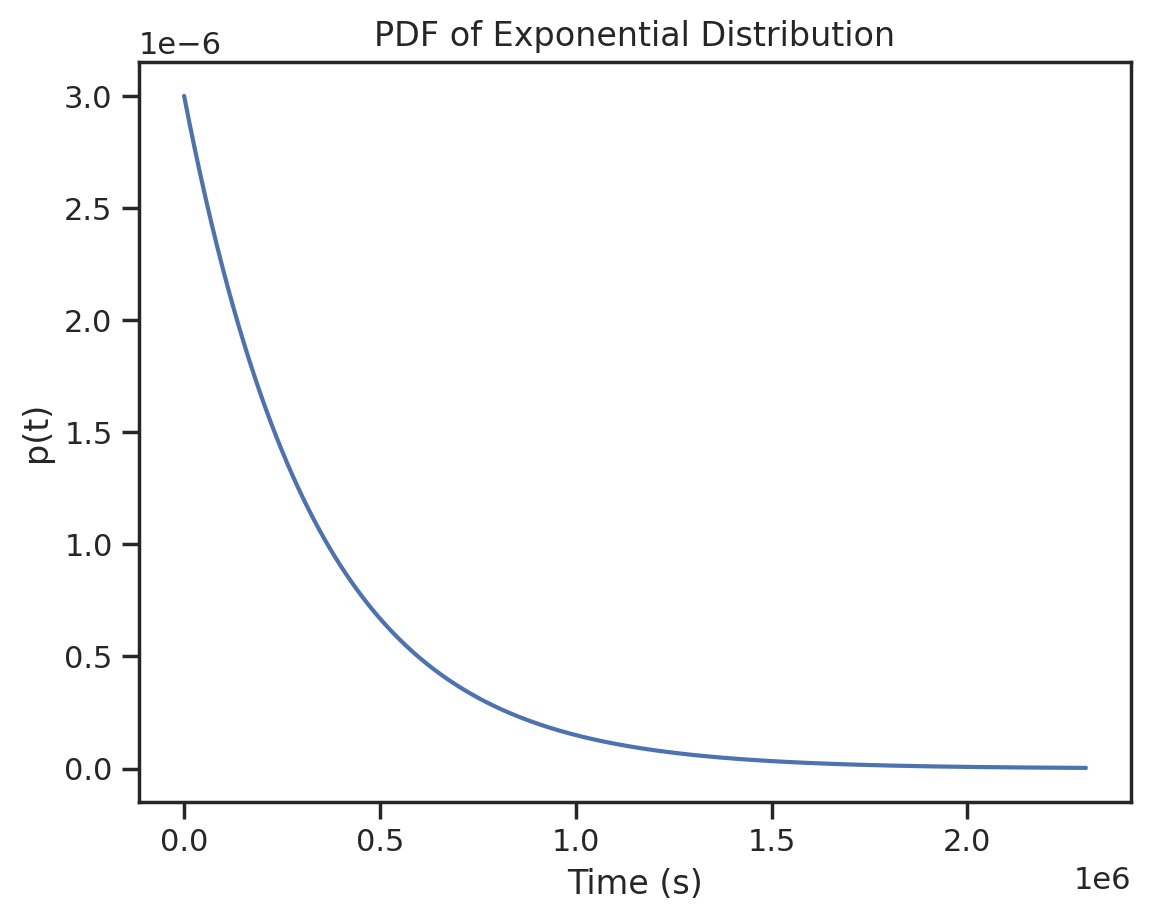

In [8]:
t = np.linspace(0, T.ppf(0.999), 500)

fig, ax = plt.subplots()
ax.plot(t, T.pdf(t))
ax.set_xlabel('Time (s)')
ax.set_ylabel('p(t)')
ax.set_title('PDF of Exponential Distribution');

Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [10]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_10.ipynb'

Mounted at /content/drive
Reading package lists...
Building dependency tree...
Reading state information...
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  aspell aspell-en at-spi2-core dictionaries-common dvisvgm enchant-2 fig2dev
  fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono fonts-texgyre
  fonts-urw-base35 gawk ghostscript glib-networking glib-networking-common
  glib-networking-services gsettings-desktop-schemas gsfonts hunspell-en-us
  imagemagick imagemagick-6-common imagemagick-6.q16 lib2geom1.1.0
  libapache-pom-java libaspell15 libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data
  libatkmm-1.6-1v5 libatspi2.0-0 libboost-filesystem1.74.0 libcairomm-1.0-1v5
  libcdr-0.1-1 libcommons-logging-java libcommons-parent-java libdbus-glib-1-2
  libdjvulibre-text libdjvulibre21 libdouble-conversion3 libenchant-2-2
  libfftw3-double3 libfontbox-java libgc1 libglibmm-2.4-1v5 libgs9